# **FASE 1: Desarrollo del Informe Técnico**
## 1. Análisis Exploratorio de Datos **(EDA)**
### Se realizara una auditoría de calidad de datos sobre el dataset inicial.
### Decidi preparar un entorno mediante la función setup de PyCaret, pero como esta librería tiene conflictos con MLflow, decidi que una vez elegido el modelo de entranamiento, pasare a la Fase2, para experimentar y subir los resultados con otro entorno de trabajo.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# El '../' lo uso para salir de la carpeta actual y mirar afuera, para de esa manera comenzar a dar consistencia y portabilidad
# a todo el proyecto.
df = pd.read_csv('../data/churn_sintetico.csv')  
print(df.head())

   tenure_months  monthly_charge  total_charges  support_tickets  \
0              7           58.23         326.50                2   
1             56           56.75        3154.21                0   
2             48           78.84        3864.31                3   
3             32           79.74        2511.40                0   
4             32           55.37        1735.51                3   

   late_payments  avg_monthly_usage_gb contract_type payment_method  \
0              1                 81.83       mensual  transferencia   
1              2                 96.52         anual         debito   
2              2                 93.60       bianual       efectivo   
3              0                 28.95       bianual         debito   
4              0                126.90         anual       efectivo   

  internet_service  has_streaming  has_security_pack  num_products  region  \
0            cable              0                  1             3  centro   
1       

In [2]:
df.shape # Para ver con que dimensión de datos estoy trabajando.

(5000, 16)

In [3]:
df.isnull().sum() # Para ver si existen datos nulos.

tenure_months           0
monthly_charge          0
total_charges           0
support_tickets         0
late_payments           0
avg_monthly_usage_gb    0
contract_type           0
payment_method          0
internet_service        0
has_streaming           0
has_security_pack       0
num_products            0
region                  0
customer_age            0
is_promo                0
churn                   0
dtype: int64

In [4]:
df.duplicated().sum() # Verificando sie tengo datos duplicados.

0

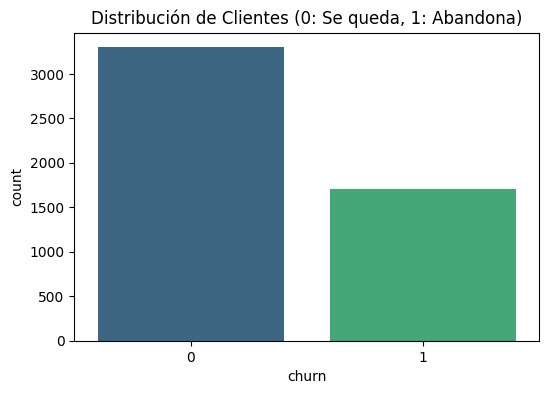

In [5]:
# Visualizar la distribución de Churn
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='churn', hue='churn', palette='viridis', legend=False)

plt.title('Distribución de Clientes (0: Se queda, 1: Abandona)')
plt.show()

## **Distribución de Clientes (Gráfico de Barras)**

### Este gráfico mide el desequilibrio de clases en el dataset.

### Donde la gran mayoría de los clientes se mantienen (0), pero tenemos una cantidad significativa de abandonos (1).

### **Interpretación:** Visualmente, parece que el churn representa aproximadamente un 30-35% de la base total.

### Para entrenar un modelo de Machine Learning más adelante, este "desbalance" es importante; si el grupo 1 fuera mucho más pequeño, tendrías que usar técnicas especiales (como sobremuestreo), para que el modelo aprenda bien a identificar a los que se van.

C:\Users\resqu\AppData\Local\Temp\ipykernel_5916\677150396.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='churn', y='tenure_months', data=df, palette='Set2')


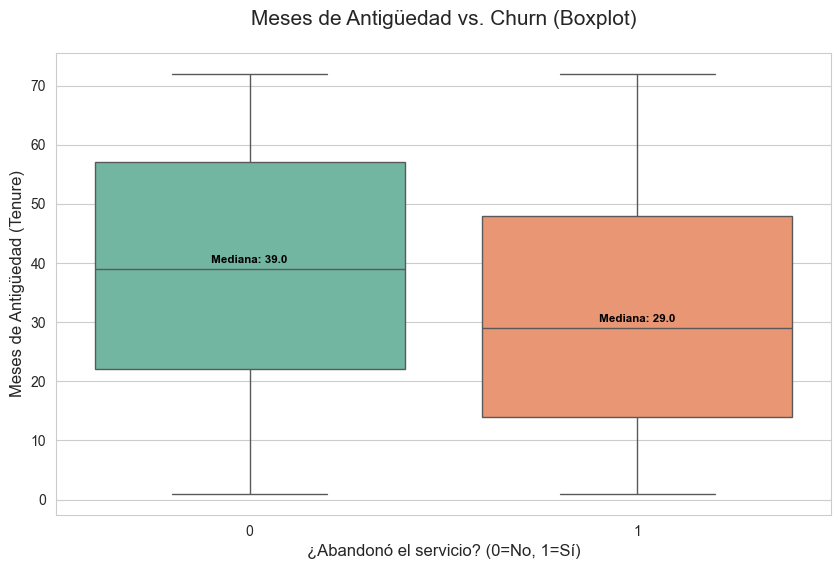

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Configuramos la ruta de guardado
ruta_reports = '../reports'
if not os.path.exists(ruta_reports):
    os.makedirs(ruta_reports)

# Configuración de estilo
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Creación del Boxplot
# Usamos 'tenure_months' contra el target 'churn'
ax = sns.boxplot(x='churn', y='tenure_months', data=df, palette='Set2')

# Personalización de títulos y etiquetas
plt.title('Meses de Antigüedad vs. Churn (Boxplot)', fontsize=15, pad=20)
plt.xlabel('¿Abandonó el servicio? (0=No, 1=Sí)', fontsize=12)
plt.ylabel('Meses de Antigüedad (Tenure)', fontsize=12)

# Añadimos una nota sobre la mediana para que sea más explicativo
medianas = df.groupby(['churn'])['tenure_months'].median()
for tick, label in enumerate(ax.get_xticklabels()):
    ax.text(tick, medianas[tick] + 1, f'Mediana: {medianas[tick]}', 
            horizontalalignment='center', size='small', color='black', weight='semibold')

# GUARDADO AUTOMÁTICO
plt.savefig(f'{ruta_reports}/boxplot_antiguedad_churn.png', dpi=300, bbox_inches='tight')

plt.show()

# **Meses de Antigüedad vs. Churn (Boxplot)**

### Aquí comparamos la "lealtad" en tiempo. El boxplot muestra la mediana (la línea negra central) y la dispersión del 50% de los datos (la caja azul).

### Osea los clientes que se quedan (0) tienen una mediana de antigüedad notablemente más alta (cerca de los 40 meses), que los que se van (1) (cuya mediana está cerca de los 30 meses).

### La hipótesis de que "los nuevos se van más" parece ser correcta. 
### La caja del grupo 1 está más abajo en el eje Y, lo que indica que el riesgo de abandono es mayor durante los primeros dos años y medio de contrato.

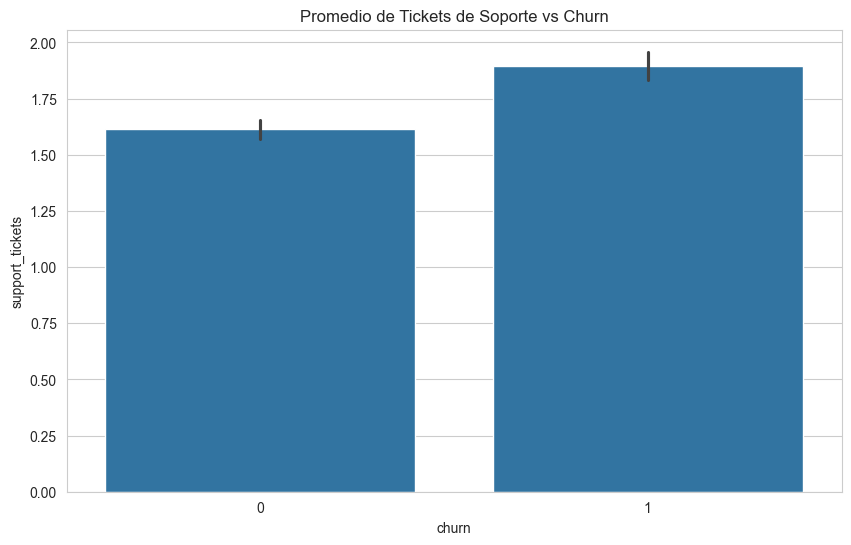

In [7]:
# Relación: Tickets de Soporte vs Churn
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='churn', y='support_tickets')
plt.title('Promedio de Tickets de Soporte vs Churn')
plt.show()

# **Promedio de Tickets de Soporte vs. Churn (Barplot con error)**

### Este gráfico muestra la relación entre la frustración técnica/administrativa y la salida del cliente.

### Existe una correlación clara. Los clientes que abandonan generan, en promedio, más tickets de soporte (cerca de 1.9) que los que se quedan (aprox. 1.6).

### La fricción en el servicio es un disparador del abandono.

### Las pequeñas líneas negras arriba de las barras (barras de error) son cortas, lo que significa que esta diferencia es estadísticamente significativa y no es resultado del azar.

# **Estrategia:**

### Tenemos un problema de retención concentrado en los clientes más nuevos (menos de 30 meses), y aquellos que experimentan problemas técnicos recurrentes (reflejado en el mayor volumen de tickets). 

### Para bajar el churn, deberíamos enfocarnos en mejorar la experiencia de soporte.

### Y crear planes de fidelización para los clientes que llevan menos de dos años con nosotros. 

In [8]:
from pycaret.classification import *

# Configuración del setup, sin MLflow para evitar errores
# PyCaret hará el encoding (dummies) y el escalado automáticamente
s = setup(
    data = df, 
    target = 'churn', 
    session_id = 123, 
    fix_imbalance = True, # Mejora las clases desbalanceadas
    normalize = True,     # Para normalizar variables numéricas
    log_experiment = False, # Desactivo MLflow
    html = True           
)

# Comparación de modelos
# Esto te mostrará la tabla con Accuracy, AUC, Recall, Precision, F1 y Kappa
print("Comparando modelos.")
best_model = compare_models()

,Description,Value
0,Session id,123
1,Target,churn
2,Target type,Binary
3,Original data shape,"(5000, 16)"
4,Transformed data shape,"(6118, 27)"
5,Transformed train set shape,"(4618, 27)"
6,Transformed test set shape,"(1500, 27)"
7,Numeric features,11
8,Categorical features,4
9,Preprocess,True


Comparando modelos.


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7114,0.7440,0.4761,0.5942,0.5279,0.3241,0.3285,1.3510
ada,Ada Boost Classifier,0.7071,0.7444,0.5147,0.5788,0.5441,0.3297,0.3313,0.5820
rf,Random Forest Classifier,0.7029,0.7291,0.4265,0.5876,0.4936,0.2910,0.2988,1.1110
lightgbm,Light Gradient Boosting Machine,0.7020,0.7219,0.4433,0.5807,0.5013,0.2950,0.3010,0.7190
et,Extra Trees Classifier,0.6957,0.7155,0.4249,0.5714,0.4865,0.2773,0.2838,0.9350
lr,Logistic Regression,0.6837,0.7525,0.7120,0.5258,0.6047,0.3508,0.3624,3.2350
ridge,Ridge Classifier,0.6803,0.7527,0.7162,0.5218,0.6035,0.3465,0.3591,0.2660
lda,Linear Discriminant Analysis,0.6800,0.7527,0.7162,0.5215,0.6033,0.3460,0.3587,0.2410
dummy,Dummy Classifier,0.6597,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2100
svm,SVM - Linear Kernel,0.6529,0.7068,0.6489,0.4924,0.5587,0.2816,0.2902,0.2660


# **Selección del Modelo**
### Tras evaluar 14 modelos para el Proyecto AndesLink, seleccione la de Regresión Logística (lr) como la opción más robusta. Este modelo logra el equilibrio, alcanzando un **F1-Score de 0.60** y con los índices **Kappa (0.3508)** y **MCC (0.3624)** más altos.

### A diferencia de otros algoritmos que presentan un sesgo hacia una sola métrica, la de Regresión Logística garantiza un **Recall del 71.2%**, permitiendo capturar a la gran mayoría de clientes en riesgo de abandono, mientras mantiene una precisión suficiente para optimizar los recursos de fidelización y reducir el impacto de los falsos positivos.

### **Próximos pasos:** Con la base de datos validada, se procedere la fase de 02_Modelado, donde realizare el ajuste de hiperparámetros y el registr de experimentos mediante MLflow.


## **Procedo a exportar información de resultados como parte del reporte**

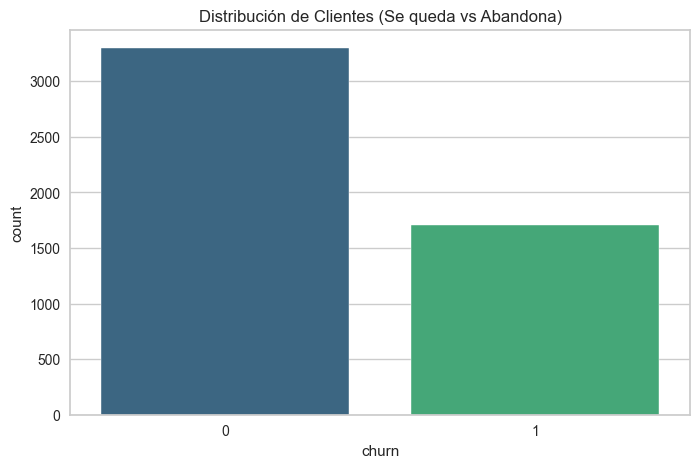

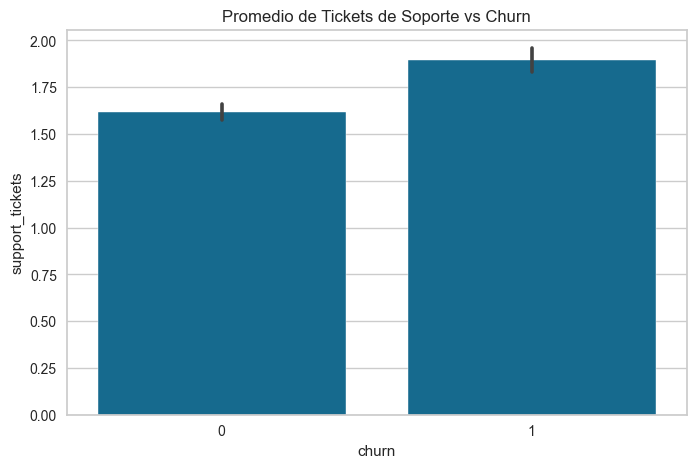

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Definimos la ruta para que suba un nivel afuera de la carpeta del notebook
# y entre en la carpeta 'reports' que está en la raíz de AndesLink
ruta_reports = '../reports'

# Distribución de Clientes 
plt.figure(figsize=(8, 5))
# Aquí va tu código de gráfico, por ejemplo:
sns.countplot(data=df, x='churn', palette='viridis')
plt.title('Distribución de Clientes (Se queda vs Abandona)')
plt.savefig(f'{ruta_reports}/distribucion_clientes.png', dpi=300, bbox_inches='tight')
plt.show()


# Tickets de Soporte
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='churn', y='support_tickets')
plt.title('Promedio de Tickets de Soporte vs Churn')
plt.savefig(f'{ruta_reports}/tickets_soporte_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()


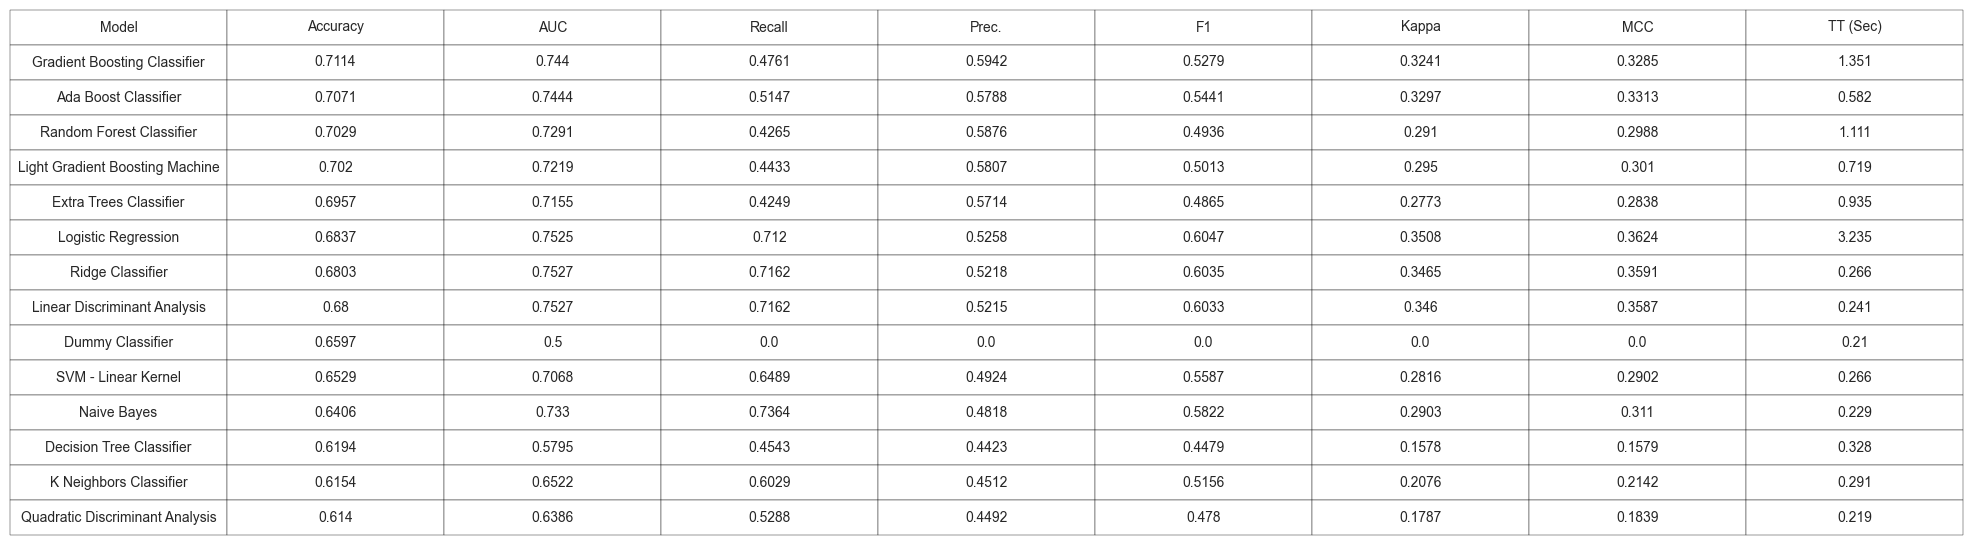

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Definimos la ruta hacia afuera (AndesLink/reports)
ruta_reports = '../reports'

# Capturamos la tabla de métricas de PyCaret
metrics_df = pull()

# Creamos la imagen de la tabla
fig, ax = plt.subplots(figsize=(12, 4)) # Ajusta el tamaño según necesites
ax.axis('off') # Ocultamos los ejes para que parezca una tabla limpia

# Dibujamos la tabla usando los datos de metrics_df
tabla = ax.table(cellText=metrics_df.values, 
                 colLabels=metrics_df.columns, 
                 cellLoc='center', 
                 loc='center')

# Estilo de la tabla
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(2.1, 2.1) # Estira la tabla para que sea legible

# Guardamos en la carpeta reports afuera
plt.savefig(f'{ruta_reports}/tabla_comparativa_modelos.png', dpi=300, bbox_inches='tight')
plt.show()